# 12 · Entrenamiento LSTM V4 multianual: prueba técnica con CCA y metodología completa

Este libro **entrena, calibra y evalúa en limpio** el LSTM V4 con 2020–2026,
según `docs/protocolo_lstm_v4_multianual.md` (§5–§7.1). Lo ejecutas tú: por
defecto **no entrena nada** y sólo muestra lo que ya esté guardado.

Los ataques (§7.2) y el daño de red (§8) van en un libro posterior: primero hay
que aceptar que los modelos entrenan bien y son reproducibles.

## Cómo usar este libro

1. Ejecuta todo tal cual (*Run All*). Como no hay modelos todavía, verás
   avisos de «sin resultados»; es normal.
2. En la sección 4 cambia `ENTRENAR = False` → `True` y vuelve a ejecutar
   esa celda. Con `OBJETIVOS = ['CCA']` entrena sólo CCA (prueba técnica,
   unos minutos en CPU).
3. Regresa `ENTRENAR = False` y ejecuta las secciones 5–6 para revisar
   el entrenamiento y la calibración.
4. Sección 7: `VERIFICAR_REPRODUCIBILIDAD = True` entrena CCA **otra vez**
   en una carpeta aparte y compara. Debe salir todo idéntico (regla del CLAUDE.md).
5. Sólo cuando 5–7 te convenzan: sección 8 con `EVALUAR_PRUEBA = True`
   para ver 2024, 2025 y 2026. **Nada de lo que veas ahí puede usarse para
   cambiar parámetros.**
6. Si CCA está bien, en la sección 4 cambia `OBJETIVOS` a la lista de
   elegibles y entrena el resto (≈2–3 h en total, se puede interrumpir y
   reanudar: los objetivos ya guardados se saltan).

### Interruptores (flags)

Un *flag* es una variable `True`/`False` que decide si una celda hace algo
costoso o irreversible. Así *Run All* nunca entrena por accidente.

| Flag | Sección | Qué hace si es `True` |
|---|---|---|
| `ENTRENAR` | 4 | Entrena los objetivos de `OBJETIVOS` que todavía no tienen modelo |
| `SUSTITUIR` | 4 | Permite sobrescribir un modelo ya guardado (déjalo en `False`) |
| `VERIFICAR_REPRODUCIBILIDAD` | 7 | Reentrena en `verificacion/` y compara con el original |
| `EVALUAR_PRUEBA` | 8 | Muestra métricas de 2024–2026 |

### Registro de progreso

Cada vez que una celda entrena, salta un objetivo, falla, verifica o muestra la
prueba, escribe una fila en `results/lstm_v4_multianual_v1/bitacora_entrenamiento.csv`
con fecha y hora, flags, objetivos pedidos y todas las variables del entrenamiento.
**Nunca se borra ni se reescribe**: si cambias `OBJETIVOS`, lo anterior sigue ahí.
La sección 9 muestra esa bitácora, el estado de los 33 objetivos y las notas escritas.

**Mensajes de TensorFlow:** al entrenar pueden salir líneas `E0000 … NodeDef
mentions attribute …` o avisos de CPU. Son avisos internos de TensorFlow, no
errores del notebook.

## 1. Glosario mínimo

| Término | Qué significa aquí |
|---|---|
| **Modelo / red neuronal** | Una función con muchos números ajustables que recibe la ventana de 24 h de las vecinas y devuelve una estimación de la estación objetivo. |
| **Pesos** | Esos números ajustables (≈35 600 en este LSTM). «Entrenar» es buscar los pesos que hacen que la estimación se parezca a la lectura real. Se guardan en `modelo.keras`. |
| **LSTM** | Tipo de red que lee la ventana hora por hora y conserva una «memoria» de lo que vio antes; útil para series de tiempo. Aquí tiene 64 unidades (tamaño de esa memoria). |
| **Ejemplo** | Un par (entrada, respuesta): la ventana 24 × 66 y la desviación real de la estación objetivo a la hora t. |
| **Época** | Una pasada completa por todos los ejemplos de entrenamiento. |
| **Batch** | Grupo de 64 ejemplos. Los pesos se corrigen después de cada batch, no después de cada ejemplo. |
| **`shuffle=True`** | En cada época los batches se presentan en orden revuelto (con la semilla 42), para que ningún mes quede siempre al final. No mezcla etapas. |
| **Pérdida (`loss`, MSE)** | Promedio del error al cuadrado en el entrenamiento, en ppb². Baja conforme el modelo aprende. |
| **`val_loss`** | La misma pérdida, pero sobre 2022, que el modelo **no** usa para ajustar pesos. Dice si lo aprendido sirve para datos nuevos. |
| **Sobreajuste** | Cuando `loss` sigue bajando pero `val_loss` sube: el modelo memoriza 2020–2021 en vez de aprender patrones generales. |
| **EarlyStopping** | Detiene la fase 1 si `val_loss` no mejora en 8 épocas seguidas (paciencia 8). |
| **E** | La época con menor `val_loss`. Es el «número de vueltas» que se usa al reentrenar con 2020–2022. |
| **Semilla 42** | Fija el azar (pesos iniciales, dropout, orden de batches) para que dos corridas den lo mismo. |
| **Dropout 0.2** | Durante el entrenamiento apaga al azar el 20 % de las conexiones; reduce el sobreajuste. |
| **Normalización** | Restar la media y dividir entre la desviación de cada estación (calculadas con el ajuste), para que todas queden en escala parecida. |
| **Máscara** | Por cada vecina y hora: 1 si hubo dato, 0 si faltó. El 0 de relleno del valor no significa 0 ppb. |
| **Seno/coseno de la hora** | La hora del día como punto en un círculo: así 23:00 y 00:00 quedan juntas. **No es la zona horaria.** |
| **Perfil (base)** | Promedio de la estación objetivo a esa hora en los 14 días anteriores. El modelo sólo aprende la **corrección** sobre ese perfil. |
| **Predicción** | `base + corrección aprendida`. |
| **Residuo** | `lectura − predicción`. Un ataque grande produce un residuo grande. |
| **p95 (umbral)** | El valor que deja por debajo al 95 % de los residuos absolutos limpios de 2023. Alerta si `|residuo| > p95`. |
| **Falsa alarma** | Alerta sobre una lectura limpia (sin ataque). |

## 2. Cómo se entrenó tu V4 de CCA (2025) y qué cambia ahora

Antes de entrenar nada nuevo, verifico con los artefactos guardados cómo era el
V4 que ya aceptaste (`notebooks/07_multiestacion.ipynb`, celda del modelo 4,
`results/modelo4_lstm.keras`). Esta sección sólo **carga**; no entrena.

In [1]:
import json, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAIZ = Path('..').resolve()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore', category=UserWarning)

from src.detect import multianual as m
from src.detect import entrenamiento_multianual as em
from src.detect.windows import construir_ventanas
from src.ingest.rama import load_wide, to_long

pd.set_option('display.width', 200)
SAL = RAIZ / 'results/lstm_v4_multianual_v1'
EST = SAL / 'estaciones'
VER = SAL / 'verificacion'
IMG = RAIZ / 'docs/img/lstm_v4_multianual_v1'
BITACORA = SAL / 'bitacora_entrenamiento.csv'   # registro de cada acción (sección 9)

In [2]:
from tensorflow import keras

meta = json.loads((RAIZ / 'results/metadatos_modelo4_cca.json').read_text())
modelo4 = keras.models.load_model(RAIZ / 'results/modelo4_lstm.keras', compile=False)
with np.load(RAIZ / 'results/preprocesamiento_modelo4_cca.npz', allow_pickle=False) as pre:
    vecinas4 = pre['vecinas'].tolist()
    corte4 = int(pre['corte'])
    ts4 = pd.DatetimeIndex(pre['timestamps'])

print('Entrada del modelo V4 guardado:', modelo4.input_shape, '→ (ejemplos, 24 horas, 66 características)')
print('Pesos ajustables:', f'{modelo4.count_params():,}')
print('Vecinas:', len(vecinas4), '| CCA entre las entradas:', 'CCA' in vecinas4)
print(f'Split 80/20 por filas: corte en la fila {corte4} = {ts4[corte4]}  (train hasta {ts4[corte4 - 1]})')
print('Épocas ejecutadas:', meta['epocas_ejecutadas'], 'de', meta['epocas_max'],
      '| validación interna:', meta['val_frac'], '| p95:', round(meta['umbral_p95_ppb'], 2), 'ppb')
modelo4.summary()

I0000 00:00:1791091159.009552  284599 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791091159.009978  284599 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791091159.040659  284599 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1791091159.946523  284599 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791091159.946846  284599 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Entrada del modelo V4 guardado: (None, 24, 66) → (ejemplos, 24 horas, 66 características)
Pesos ajustables: 35,649
Vecinas: 32 | CCA entre las entradas: False
Split 80/20 por filas: corte en la fila 7008 = 2025-10-20 00:00:00  (train hasta 2025-10-19 23:00:00)
Épocas ejecutadas: 30 de 60 | validación interna: 0.2 | p95: 14.75 ppb


E0000 00:00:1791091160.534742  284599 cuda_platform.cc:57] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
=== Source Location Trace: ===
external/xla/xla/stream_executor/cuda/cuda_status.cc:50



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        33,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,649 (139.25 KB)

 Trainable params: 35,649 (139.25 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Una ventana real del V4, construida con la misma función de 2025, para ver seno y coseno.
mat25 = (to_long(load_wide(RAIZ / 'data/raw/2025O3.xls'), 'O3')
         .pivot(index='timestamp', columns='station', values='value').dropna(axis=1, how='all'))
X25, *_ = construir_ventanas(mat25.iloc[:200], 'CCA', ventana=24)
ventana = pd.DataFrame(X25[0], index=mat25.index[0:24], columns=[f'{c}_valor' for c in vecinas4]
                       + [f'{c}_mascara' for c in vecinas4] + ['hora_sin', 'hora_cos'])
print('Primera ventana del V4 (24 filas = 24 horas de contexto; objetivo:', mat25.index[24], ')')
print(ventana[['ACO_valor', 'ACO_mascara', 'hora_sin', 'hora_cos']].round(3).assign(hora=ventana.index.hour).to_string())

Primera ventana del V4 (24 filas = 24 horas de contexto; objetivo: 2025-01-02 00:00:00 )
                     ACO_valor  ACO_mascara  hora_sin  hora_cos  hora
timestamp                                                            
2025-01-01 00:00:00        0.0          0.0     0.000     1.000     0
2025-01-01 01:00:00        0.0          0.0     0.259     0.966     1
2025-01-01 02:00:00        0.0          0.0     0.500     0.866     2
2025-01-01 03:00:00        0.0          0.0     0.707     0.707     3
2025-01-01 04:00:00        0.0          0.0     0.866     0.500     4
2025-01-01 05:00:00        0.0          0.0     0.966     0.259     5
2025-01-01 06:00:00        0.0          0.0     1.000     0.000     6
2025-01-01 07:00:00        0.0          0.0     0.966    -0.259     7
2025-01-01 08:00:00        0.0          0.0     0.866    -0.500     8
2025-01-01 09:00:00        0.0          0.0     0.707    -0.707     9
2025-01-01 10:00:00        0.0          0.0     0.500    -0.866    10
2

**Lo que se comprueba arriba:**

- El V4 recibe **24 horas × 66 características**: 32 vecinas normalizadas, sus
  32 máscaras y 2 columnas de hora. CCA **no** está entre sus entradas.
- `hora_sin` y `hora_cos` son la hora de **cada fila del contexto**: en la
  fila de las 00:00, seno 0 y coseno 1; a las 06:00, seno 1 y coseno 0; y así
  hasta cerrar el círculo. El modelo deduce la hora objetivo porque siempre es
  la hora siguiente a la última fila. No interviene la zona horaria: las
  horas son las del archivo SIMAT (convención provisional `HORA=1 → 00:00`).
- El modelo aprende la **desviación respecto al perfil de 14 días**, no el
  valor absoluto.

### V4 2025 frente a V4 multianual

| Aspecto | V4 CCA 2025 (aceptado) | V4 multianual (este libro) | ¿Por qué cambia? |
|---|---|---|---|
| Datos | 2025, 8 760 h | 2020 – jul 2026, 57 696 h | más años y temporada alta en prueba |
| Columnas | las que no estaban vacías en 2025 (33) | las mismas 33, fijas todos los años | otro año daría otro número de columnas |
| Entrada | 24 × 66, sin/cos por fila | **idéntica** (probado en `tests/test_entrenamiento_multianual.py`) | — |
| Arquitectura | LSTM 64, dropout 0.2, densa 32, salida 1 | **idéntica** (`construir_modelo`) | — |
| Optimizador, batch, semilla | Adam 0.001, 64, 42 | idénticos | — |
| Separación | 80/20 por filas; validación = último 20 % del train | por años: 2020–21 / 2022 / 2023 / 2024–26 | etapas independientes y estaciones completas |
| Épocas | EarlyStopping dentro del mismo entrenamiento (30) | fase 1 elige E con 2022; fase 2 reentrena 2020–22 E épocas | el modelo final también aprende de 2022 |
| `shuffle` | `True` (valor por defecto de Keras) | `True`, explícito | — |
| Perfil, respaldo de arranque | media global de **toda** la serie (no causal) | media histórica **anterior a t** | evitar información del futuro |
| Contexto en el corte | se descartaban las primeras 24 h del test | se usa el contexto de la etapa anterior | no perder ejemplos |
| Canal sin historia | no aplicaba | XAL oculto (valor 0, máscara 0) | sus pesos no se entrenarían |
| Umbral | p95 del train (14.75) y operativo 22.6 | p95 propio de 2023 por estación | calibrar fuera del entrenamiento |

Los números del V4 de 2025 **no** se comparan uno a uno con los de este libro:
son otro periodo, otro protocolo y otro umbral.

## 3. Base temporal común

Carga la matriz y las normalizaciones construidas en el notebook 11. Tarda unos segundos.

In [4]:
ctx = em.contexto(RAIZ)
cob = pd.read_csv(SAL / 'cobertura_etapas.csv')
clases = cob.drop_duplicates('objetivo').set_index('objetivo')[['clasificacion', 'motivo']]
ELEGIBLES = [s for s in m.ESTACIONES if clases.at[s, 'clasificacion'] != 'fuera']
print('Matriz:', ctx['valores'].shape, '| canales inactivos:', ctx['definitiva']['inactivos'])
print(f'Elegibles ({len(ELEGIBLES)}):', ' '.join(ELEGIBLES))
print('Fuera:', clases.index[clases.clasificacion == 'fuera'].tolist())
print('Baja representatividad (se entrenan, se reportan aparte):',
      clases.index[clases.clasificacion == 'baja_representatividad'].tolist())

Matriz: (57696, 33) | canales inactivos: ['XAL']
Elegibles (31): ACO AJM AJU ATI BJU CAM CCA CHO CUA CUT FAC FAR GAM INN IZT LLA LPR MER MGH MON MPA NEZ PED SAC SAG TAH TLA TLI UAX UIZ VIF
Fuera: ['HGM', 'XAL']
Baja representatividad (se entrenan, se reportan aparte): ['AJM', 'INN', 'TLI']


## 4. Entrenamiento

**Qué pasa por cada objetivo cuando `ENTRENAR = True`:**

1. **Fase 1, selección.** Modelo nuevo con semilla 42; entrena con 2020–2021 y
   después de cada época mide `val_loss` en 2022. EarlyStopping lo detiene si
   en 8 épocas no mejora. Se elige **E** = época con menor `val_loss`.
2. **Fase 2, definitivo.** Otro modelo nuevo, otra vez semilla 42, normalización
   recalculada con 2020–2022; entrena **exactamente E épocas** con 2020–2022,
   sin validación. Este es el modelo que se guarda (`modelo.keras`).
3. **Calibración.** Se recarga el modelo desde disco y se predice 2023 → p95.
4. **Predicción limpia.** Mismo modelo, mismo umbral, sobre 2024, 2025 y 2026.

Si un objetivo ya tiene `modelo.keras`, se salta (no se reentrena ni sobrescribe).
Para CCA espera ≈5 s por época y fase.

In [5]:
ENTRENAR = False          # ← cambia a True para entrenar
SUSTITUIR = False         # ← déjalo en False: no sobrescribir modelos guardados
OBJETIVOS = ['CCA']       # prueba técnica; después: OBJETIVOS = ELEGIBLES
VERBOSE = 1               # 1 = muestra una barra por época; 0 = silencioso

import time
FLAGS = dict(ENTRENAR=ENTRENAR, SUSTITUIR=SUSTITUIR, OBJETIVOS=OBJETIVOS)
if ENTRENAR:
    errores = []
    for i, obj in enumerate(OBJETIVOS, 1):
        carpeta = EST / obj
        flags = dict(FLAGS, clasificacion=clases.at[obj, 'clasificacion'])
        if (carpeta / 'modelo.keras').exists() and not SUSTITUIR:
            print(f'{i:02d}/{len(OBJETIVOS)} {obj}: ya entrenado, se salta.')
            em.registrar(BITACORA, 'entrenar', obj, 'saltado_ya_existe', flags=flags, carpeta=carpeta,
                         config=json.loads((carpeta / 'configuracion.json').read_text()))
            continue
        if clases.at[obj, 'clasificacion'] == 'fuera':
            print(f'{i:02d}/{len(OBJETIVOS)} {obj}: fuera del protocolo ({clases.at[obj, "motivo"]}).')
            em.registrar(BITACORA, 'entrenar', obj, 'fuera_del_protocolo', clases.at[obj, 'motivo'], flags=flags)
            continue
        t0 = time.time()
        try:
            cfg = em.entrenar_objetivo(ctx, obj, carpeta, sustituir=SUSTITUIR, verbose=VERBOSE)
        except Exception as e:                       # se registra y se sigue con el siguiente
            errores.append(obj)
            print(f'{i:02d}/{len(OBJETIVOS)} {obj}: ERROR {type(e).__name__}: {e}')
            em.registrar(BITACORA, 'entrenar', obj, 'error', f'{type(e).__name__}: {e}', flags=flags,
                         carpeta=carpeta, segundos=time.time() - t0)
            continue
        em.registrar(BITACORA, 'entrenar', obj, 'entrenado', flags=flags, config=cfg, carpeta=carpeta,
                     segundos=time.time() - t0)
        print(f'{i:02d}/{len(OBJETIVOS)} {obj}: E={cfg["epoca_E"]}, p95={cfg["umbral_p95_ppb"]:.2f} ppb, '
              f'{time.time() - t0:.0f} s', flush=True)
    if errores:
        print('\nObjetivos con error (ver bitácora):', errores)
else:
    print('ENTRENAR = False: no se entrena. Objetivos ya guardados:',
          sorted(p.parent.name for p in EST.glob('*/modelo.keras')) or 'ninguno')

ENTRENAR = False: no se entrena. Objetivos ya guardados: ['CCA']


## 5. Revisión del entrenamiento (sin mirar la prueba)

**Cómo leer las curvas:**

- Izquierda, **fase 1**. `loss` (entrenamiento) debe bajar. `val_loss` (2022)
  baja al principio y luego se estabiliza o sube. La línea vertical es **E**.
  Si `val_loss` sube mucho después de E, hubo sobreajuste y EarlyStopping hizo
  su trabajo. Si E es la última época posible (60), el modelo quizá seguía
  aprendiendo: anótalo, no lo cambies.
- Derecha, **fase 2**. Sólo `loss`, durante E épocas: debe bajar de forma
  parecida a la fase 1. No hay `val_loss` porque 2022 ya es parte del ajuste.
- `loss` está en ppb² (MSE de la desviación); su raíz da una idea del error típico en ppb.

### De dónde sale cada número de esta sección

| Número | Archivo | Cómo se calcula | Qué significa |
|---|---|---|---|
| `loss` | `seleccion/historia_seleccion.csv`, `historia_definitiva.csv` | Keras, al final de cada época: promedio de `(desviación real − corrección predicha)²` sobre los ejemplos de **entrenamiento** | Qué tan bien reproduce lo que está aprendiendo. Siempre baja; por sí solo no dice si generaliza. |
| `mae` | mismos archivos | promedio de `|desviación real − corrección predicha|` en entrenamiento | Lo mismo en ppb, más fácil de leer que el MSE. |
| `val_loss`, `val_mae` | `historia_seleccion.csv` | igual que `loss`/`mae`, pero sobre **2022**, sin ajustar pesos con esos ejemplos | La señal honesta: si baja, lo aprendido sirve para un año que el modelo no vio. |
| `E` (`epoca_E`) | `configuracion.json` | `argmin(val_loss) + 1` (primera época con el mínimo) | Cuántas épocas se repiten en la fase 2. |
| `epocas_seleccion_ejecutadas` | `configuracion.json` | E + las épocas que esperó EarlyStopping (≤ 8) | Si es 60 y E también, el modelo no había terminado de mejorar. |
| `n_ajuste_inicial`, `n_validacion`, … | `configuracion.json` | número de ejemplos efectivos de cada etapa (objetivo válido, base disponible) | Cuántos datos hubo en cada etapa; debe coincidir con `cobertura_etapas.csv`. |

**Una brecha grande entre `loss` y `val_loss`** (entrenamiento mucho mejor que 2022)
indica sobreajuste o que los años son distintos entre sí (deriva). E pequeño
significa que la parte útil se aprende en pocas épocas.

CCA: E = 2 de 10 épocas ejecutadas en la fase 1 (máximo 60).
Ejemplos — ajuste inicial 16,184 · validación 8,342 · ajuste definitivo 24,526 · calibración 8,156
val_loss mínimo 154.0 ppb² → raíz ≈ 12.4 ppb


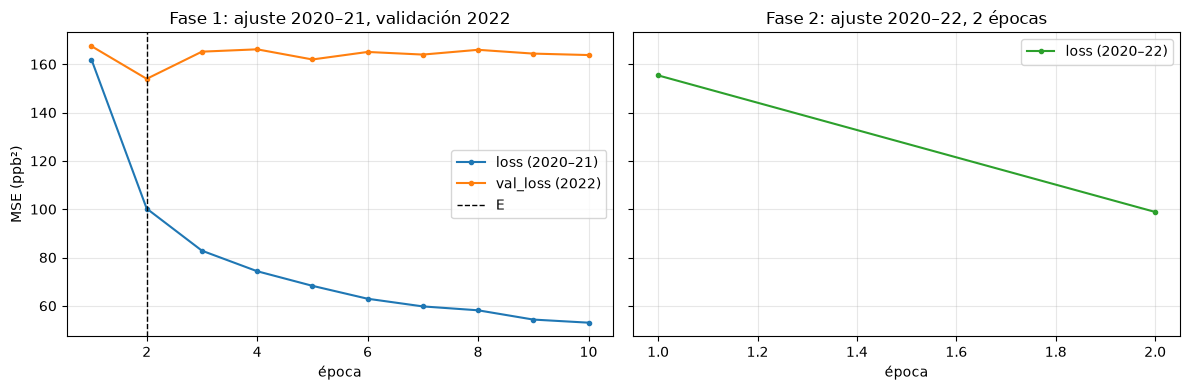

In [6]:
REVISAR = 'CCA'
res = em.cargar_objetivo(EST / REVISAR)
if res is None:
    print(f'{REVISAR}: sin resultados todavía (entrena en la sección 4).')
else:
    cfg = res['config']
    print(f"{REVISAR}: E = {cfg['epoca_E']} de {cfg['epocas_seleccion_ejecutadas']} épocas ejecutadas en la fase 1 "
          f"(máximo {cfg['max_epocas']}).")
    print(f"Ejemplos — ajuste inicial {cfg['n_ajuste_inicial']:,} · validación {cfg['n_validacion']:,} · "
          f"ajuste definitivo {cfg['n_ajuste_definitivo']:,} · calibración {cfg['n_calibracion']:,}")
    print(f"val_loss mínimo {cfg['val_loss_minimo']:.1f} ppb² → raíz ≈ {np.sqrt(cfg['val_loss_minimo']):.1f} ppb")
    fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    res['seleccion'][['loss', 'val_loss']].plot(ax=ax[0], marker='.')
    ax[0].axvline(cfg['epoca_E'], color='k', ls='--', lw=1, label=f"E = {cfg['epoca_E']}")
    ax[0].set_title('Fase 1: ajuste 2020–21, validación 2022'); ax[0].legend(['loss (2020–21)', 'val_loss (2022)', 'E'])
    res['definitiva'][['loss']].plot(ax=ax[1], marker='.', color='C2')
    ax[1].set_title(f'Fase 2: ajuste 2020–22, {cfg["epoca_E"]} épocas'); ax[1].legend(['loss (2020–22)'])
    for a in ax:
        a.set_xlabel('época'); a.set_ylabel('MSE (ppb²)'); a.grid(alpha=.3)
    fig.tight_layout(); plt.show()

## 6. Calibración 2023

El p95 se calcula con los residuos absolutos de 2023, que el modelo nunca vio al
entrenar. Se muestran también por mes para ver si 2023 tiene meses poco
representados (en TLI e INN hay pocos datos de calibración).

`mae_solo_perfil` es el error que tendrías **sin** LSTM, usando sólo el perfil de
14 días. Si el LSTM no lo mejora, la corrección aprendida no está aportando.

### De dónde sale cada métrica (sección 6 y sección 8)

Todas salen de los archivos `calibracion_2023.csv.gz` o `predicciones_<año>.csv.gz`
del objetivo, calculadas con `em.metricas_limpias`. En cada fila hay una lectura
limpia (sin ataque): `original_ppb` (lo que midió la estación), `base_ppb` (perfil
de 14 días), `predicho_ppb` (base + corrección del LSTM) y
`residuo_ppb = original − predicho`.

| Métrica | Fórmula | Unidad | Cómo leerla |
|---|---|---|---|
| `n` | número de filas | lecturas | Cuántas lecturas válidas se evaluaron. |
| `mae` | promedio de `|residuo|` | ppb | Error típico **sin signo**: «en promedio me equivoco por tantos ppb». Menor es mejor. |
| `sesgo` | promedio de `residuo` (con signo) | ppb | Si se equivoca más hacia un lado. **+** = el modelo **subestima** (la lectura real suele ser mayor); **−** = sobreestima. Cerca de 0 es bueno, pero puede ocultar sesgos opuestos que se cancelan (ver la tabla por hora). |
| `sigma` | desviación estándar de `residuo` (`ddof=0`) | ppb | Ancho del error alrededor del sesgo. Con errores aproximadamente normales, ≈68 % cae dentro de ±1 sigma y ≈95 % dentro de ±2. |
| RMSE | raíz del promedio de `residuo²` | ppb | Como el MAE, pero castiga más los errores grandes. ≈ √(sesgo² + sigma²). |
| `umbral` (p95) | percentil 95 de `|residuo|` en **2023** | ppb | El 95 % de las lecturas limpias de 2023 tiene un error menor. Es el corte del detector: alerta si `|residuo| > umbral`. |
| `falsas_alarmas` | cuántas lecturas limpias tienen `|residuo| > umbral` | lecturas | Alertas sin ataque. |
| `fpr` | `falsas_alarmas / n` | fracción | Tasa de falsas alarmas. En 2023 es ≈0.05 **por construcción** (así se eligió el p95); en otros años es lo que hay que medir. |
| `mae_solo_perfil`, `sesgo_solo_perfil` | igual, con `original − base` | ppb | El mismo error si no hubiera LSTM. La diferencia con `mae` es lo que aporta el modelo. |

El **detector** usa sólo el residuo y el umbral. Un ataque que desplaza la lectura
k ppb suma k al residuo: si el error limpio ya es grande a esa hora, el ataque se
confunde con él.

Umbral p95 de CCA: 24.1559 ppb  (alerta si |residuo| > umbral)
n                    8156.000
mae                     8.593
sesgo                   1.080
sigma                  11.634
falsas_alarmas        408.000
fpr                     0.050
mae_solo_perfil        10.667
sesgo_solo_perfil      -0.045
RMSE LSTM 11.68 ppb | RMSE solo perfil 14.78 ppb
Dentro de ±1 sigma: 74.0% | dentro de ±2 sigma: 94.3% | umbral = 2.08 sigma

Por hora del día (sesgo + = el modelo subestima):
hora    0    1    2    3    4    5    6    7    8    9     10    11    12    13    14    15    16    17    18    19   20   21   22   23
mae    6.4  6.6  6.6  6.2  6.0  5.1  3.9  3.5  4.8  6.3   8.2  10.1  12.1  14.2  14.2  14.1  13.5  13.4  10.5  10.0  7.9  7.7  7.3  7.0
sesgo -0.2 -1.1 -1.7 -2.4 -2.3 -2.5 -1.7 -0.6 -0.5 -0.7   1.4   3.8   6.1   7.9   6.6   6.2   5.2   2.3   0.0  -0.3 -0.4 -0.1  0.2  0.2
sigma  8.0  8.1  7.9  7.4  7.0  5.8  4.7  4.6  6.3  8.1  10.4  12.2  14.2  16.4  17.6  16.6  16.0  16.1  13.3  12

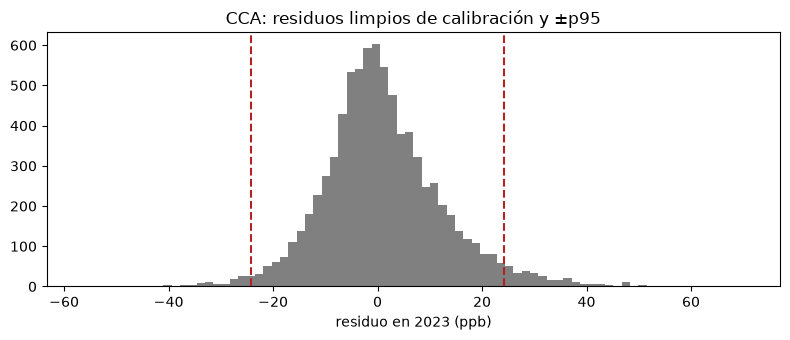

In [7]:
if res is not None and res['calibracion'] is not None:
    cal, u = res['calibracion'], res['umbral']
    met = em.metricas_limpias(cal, u)
    print(f"Umbral p95 de {REVISAR}: {u:.4f} ppb  (alerta si |residuo| > umbral)")
    print(pd.Series(met).round(3).to_string())
    mes = cal.assign(mes=cal.timestamp.dt.month, abs_res=cal.residuo_ppb.abs())
    r = cal.residuo_ppb
    print(f"RMSE LSTM {np.sqrt((r ** 2).mean()):.2f} ppb | RMSE solo perfil "
          f"{np.sqrt(((cal.original_ppb - cal.base_ppb) ** 2).mean()):.2f} ppb")
    sd = r.std(ddof=0)
    print(f"Dentro de ±1 sigma: {(r.abs() <= sd).mean():.1%} | dentro de ±2 sigma: {(r.abs() <= 2 * sd).mean():.1%}"
          f" | umbral = {u / sd:.2f} sigma")
    print('\nPor hora del día (sesgo + = el modelo subestima):')
    hora = cal.assign(hora=cal.timestamp.dt.hour, abs_res=cal.residuo_ppb.abs())
    print(hora.groupby('hora').agg(mae=('abs_res', 'mean'), sesgo=('residuo_ppb', 'mean'),
                                   sigma=('residuo_ppb', lambda x: x.std(ddof=0))).round(1).T.to_string())
    print('\nPor mes de 2023:')
    print(mes.groupby('mes').agg(n=('abs_res', 'size'), mae=('abs_res', 'mean'),
                                 p95_mes=('abs_res', lambda r: np.percentile(r, 95))).round(2).to_string())
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.hist(cal.residuo_ppb, bins=80, color='0.5')
    for s in (-1, 1):
        ax.axvline(s * u, color='firebrick', ls='--')
    ax.set_xlabel('residuo en 2023 (ppb)'); ax.set_title(f'{REVISAR}: residuos limpios de calibración y ±p95')
    fig.tight_layout(); plt.show()
else:
    print('Sin calibración todavía.')

## 7. Reproducibilidad

El CLAUDE.md exige correr el mismo entrenamiento dos veces y confirmar que no
cambia. Con `VERIFICAR_REPRODUCIBILIDAD = True` se entrena el objetivo de nuevo
en `results/lstm_v4_multianual_v1/verificacion/<ESTACIÓN>/` (nunca encima del
original) y se comparan E, todos los pesos, el p95 y cada predicción.
Esperado: **todo `True`**. Si algo sale `False`, no aceptar resultados y avisar.

| Comprobación | Qué compara |
|---|---|
| `epoca_E` | Que la fase 1 elija la misma época en las dos corridas. |
| `pesos idénticos` | Los 7 arreglos de números del modelo (pesos y sesgos de LSTM y capas densas), valor por valor. |
| `umbral p95 idéntico` | El p95 de 2023 con todos sus decimales. |
| `calibracion_2023`, `predicciones_<año>` | Cada fila de cada archivo de predicciones. |

No se compara el hash del archivo `.keras`: puede cambiar por metadatos de guardado
aunque los pesos sean idénticos.

In [8]:
VERIFICAR_REPRODUCIBILIDAD = False   # ← True para reentrenar y comparar
OBJETIVO_VERIFICAR = 'CCA'

if VERIFICAR_REPRODUCIBILIDAD:
    if not (EST / OBJETIVO_VERIFICAR / 'modelo.keras').exists():
        raise FileNotFoundError('Primero entrena el original en la sección 4.')
    if not (VER / OBJETIVO_VERIFICAR / 'modelo.keras').exists():
        em.entrenar_objetivo(ctx, OBJETIVO_VERIFICAR, VER / OBJETIVO_VERIFICAR, verbose=0)
if (VER / OBJETIVO_VERIFICAR / 'modelo.keras').exists():
    comp = em.comparar_corridas(EST / OBJETIVO_VERIFICAR, VER / OBJETIVO_VERIFICAR)
    print(comp.to_string(index=False))
    print('\nREPRODUCIBLE:', bool(comp.identico.all()))
    if VERIFICAR_REPRODUCIBILIDAD:   # sólo se registra cuando se pidió la verificación
        em.registrar(BITACORA, 'verificar', OBJETIVO_VERIFICAR,
                     'reproducible' if comp.identico.all() else 'no_reproducible',
                     '; '.join(f'{r.comprobacion}={r.identico}' for r in comp.itertuples()),
                     flags=dict(VERIFICAR_REPRODUCIBILIDAD=True), carpeta=VER / OBJETIVO_VERIFICAR,
                     config=json.loads((VER / OBJETIVO_VERIFICAR / 'configuracion.json').read_text()))
else:
    print('Sin corrida de verificación todavía.')

            comprobacion  identico                                  detalle
                 epoca_E      True                                   2 vs 2
         pesos idénticos      True                                 7 arrays
     umbral p95 idéntico      True 24.155933690922595 vs 24.155933690922595
 calibracion_2023.csv.gz      True                               8156 filas
predicciones_2024.csv.gz      True                               8166 filas
predicciones_2025.csv.gz      True                               8491 filas
predicciones_2026.csv.gz      True                               4727 filas

REPRODUCIBLE: True


## 8. Evaluación limpia en prueba (2024, 2025, 2026)

> ⚠️ A partir de aquí se mira la prueba. El protocolo ya está congelado:
> lo que veas **no** puede usarse para cambiar épocas, umbrales, estaciones ni
> arquitectura. Si algo te hace querer cambiarlo, se registra como protocolo nuevo.

Las columnas son las mismas de la tabla de la sección 6 (ahí está de dónde sale
cada una). Resumen: `n` lecturas evaluadas; `mae` error absoluto
medio (ppb); `sesgo` media de `lectura − predicción` (positivo = el modelo
subestima); `sigma` dispersión del residuo; `falsas_alarmas` y `fpr` alertas
sobre lecturas limpias y su proporción (el p95 apuntaba a ≈5 % en 2023, pero en
otro año puede ser distinto); `*_solo_perfil` lo mismo sin LSTM.
2026 cubre sólo enero–julio: no compararlo como año completo.

In [9]:
EVALUAR_PRUEBA = False   # ← True sólo después de revisar las secciones 5–7

def tabla_limpia(objetivos):
    filas = []
    for obj in objetivos:
        r = em.cargar_objetivo(EST / obj)
        if r is None:
            continue
        for anio, pred in r['prueba'].items():
            filas.append(dict(objetivo=obj, anio=anio, clasificacion=clases.at[obj, 'clasificacion'],
                              umbral=r['umbral'], **em.metricas_limpias(pred, r['umbral'])))
    return pd.DataFrame(filas)

if EVALUAR_PRUEBA:
    limpias = tabla_limpia(m.ESTACIONES)
    if limpias.empty:
        print('No hay objetivos entrenados.')
    else:
        limpias.to_csv(SAL / 'metricas_limpias.csv', index=False)
        print(limpias.round(3).to_string(index=False))
        # Deja constancia de CUÁNDO y de QUÉ objetivos se miró la prueba (protocolo §2).
        em.registrar(BITACORA, 'evaluar_prueba', ' '.join(sorted(limpias.objetivo.unique())), 'mostrada',
                     'años: ' + ' '.join(map(str, sorted(limpias.anio.unique()))),
                     flags=dict(EVALUAR_PRUEBA=True))
else:
    print('EVALUAR_PRUEBA = False: no se muestran métricas de prueba.')

EVALUAR_PRUEBA = False: no se muestran métricas de prueba.


In [10]:
if EVALUAR_PRUEBA and (EST / REVISAR / 'configuracion.json').exists():
    r = em.cargar_objetivo(EST / REVISAR)
    for anio, pred in r['prueba'].items():
        p = pred.assign(mes=pred.timestamp.dt.month, hora=pred.timestamp.dt.hour,
                        abs_res=pred.residuo_ppb.abs(), alerta=pred.residuo_ppb.abs() > r['umbral'])
        print(f'\n{REVISAR} {anio} — por mes:')
        print(p.groupby('mes').agg(n=('abs_res', 'size'), mae=('abs_res', 'mean'),
                                   sesgo=('residuo_ppb', 'mean'), fpr=('alerta', 'mean')).round(3).to_string())
    pred = r['prueba'][2024]
    fig, ax = plt.subplots(figsize=(13, 4))
    tramo = pred[(pred.timestamp >= '2024-05-01') & (pred.timestamp < '2024-05-15')]
    ax.plot(tramo.timestamp, tramo.original_ppb, label='lectura', lw=1)
    ax.plot(tramo.timestamp, tramo.predicho_ppb, label='predicción LSTM', lw=1)
    ax.plot(tramo.timestamp, tramo.base_ppb, label='perfil 14 d', lw=0.8, ls=':')
    ax.axhline(155, color='firebrick', ls='--', lw=0.8, label='155 ppb')
    ax.set_title(f'{REVISAR}: 1–14 mayo 2024 (temporada alta), datos limpios'); ax.legend(fontsize=8)
    fig.tight_layout(); plt.show()

## 9. Registro de progreso y estado de los objetivos

Tres piezas, de la más automática a la más interpretativa:

1. **Bitácora automática** (`bitacora_entrenamiento.csv`): una fila por acción.
   Las filas con `origen_registro = reconstruido…` se agregaron a mano a partir de
   las fechas y archivos de corridas hechas antes de que existiera el registro.
2. **Estado de los 33 objetivos** (`estado_objetivos.csv`): se recalcula con lo
   que hay en disco cada vez que ejecutas esta sección.
3. **Notas escritas** (abajo): qué se decidió y cómo se interpretó. Agrega una
   entrada nueva por cada sesión; no edites las anteriores.

**Columnas de la bitácora:** `accion` y `resultado` (qué se hizo y cómo terminó);
los flags y `OBJETIVOS` vigentes en ese momento; `clasificacion` del objetivo;
`epoca_E`, `epocas_seleccion_ejecutadas`, `val_loss_minimo`, los `n_*` de cada
etapa y `umbral_p95_ppb` (ver tablas de las secciones 5 y 6); `segundos` de
duración; la configuración (`semilla`, `unidades`, `batch`, `max_epocas`,
`paciencia`, `shuffle`, `canales_inactivos`), versiones y hash del modelo.

**Columnas del estado:** `entrenado`, `verificado` (sí / no / DIFIERE),
`E_en_maximo` (True = E llegó a 60, el modelo quizá seguía mejorando),
`loss_final_fase2`, `umbral_p95`, `anios_prueba` con predicciones y, sobre 2023,
`mae_cal`, `sesgo_cal`, `sigma_cal`, `mae_perfil_cal` y `mejora_vs_perfil_pct`
(cuánto reduce el LSTM el MAE frente a usar sólo el perfil). No incluye métricas
de prueba: ésas están en la sección 8.

In [11]:
bit = em.leer_bitacora(BITACORA)
print(f'Bitácora: {len(bit)} filas')
if len(bit):
    print(bit[['fecha_hora', 'accion', 'objetivo', 'resultado', 'epoca_E', 'umbral_p95_ppb',
               'segundos', 'OBJETIVOS', 'origen_registro']].to_string(index=False))

Bitácora: 2 filas
               fecha_hora    accion objetivo    resultado epoca_E     umbral_p95_ppb segundos OBJETIVOS                                                               origen_registro
2026-10-03T23:00:06-06:00  entrenar      CCA    entrenado       2 24.155933690922595                CCA reconstruido 2026-10-03 desde fechas de archivos (corrida previa al registro)
2026-10-03T23:07:45-06:00 verificar      CCA reproducible       2 24.155933690922595                    reconstruido 2026-10-03 desde fechas de archivos (corrida previa al registro)


In [12]:
estado = em.estado_objetivos(EST, VER, clases)
estado.to_csv(SAL / 'estado_objetivos.csv', index=False)
print(f"Entrenados: {int(estado.entrenado.sum())}/{len(estado)} | "
      f"elegibles sin entrenar: {[o for o in ELEGIBLES if not estado.set_index('objetivo').at[o, 'entrenado']]}")
print(estado.to_string(index=False))

Entrenados: 1/33 | elegibles sin entrenar: ['ACO', 'AJM', 'AJU', 'ATI', 'BJU', 'CAM', 'CHO', 'CUA', 'CUT', 'FAC', 'FAR', 'GAM', 'INN', 'IZT', 'LLA', 'LPR', 'MER', 'MGH', 'MON', 'MPA', 'NEZ', 'PED', 'SAC', 'SAG', 'TAH', 'TLA', 'TLI', 'UAX', 'UIZ', 'VIF']
objetivo          clasificacion                                     motivo  entrenado verificado  epoca_E  epocas_fase1 E_en_maximo  val_loss_min  loss_final_fase2  n_ajuste_def  n_calibracion  umbral_p95   anios_prueba  mae_cal  sesgo_cal  sigma_cal  mae_perfil_cal  mejora_vs_perfil_pct
     ACO              principal                                        NaN      False         no      NaN           NaN         NaN           NaN               NaN           NaN            NaN         NaN            NaN      NaN        NaN        NaN             NaN                   NaN
     AJM baja_representatividad     ajuste_inicial: 2489 ejemplos, 4 meses      False         no      NaN           NaN         NaN           NaN               NaN     

### Notas escritas (bitácora narrativa)

#### 2026-10-03 — Prueba técnica con CCA

- **Qué se hizo:** `ENTRENAR = True`, `OBJETIVOS = ['CCA']` (22:59–23:00);
  después `VERIFICAR_REPRODUCIBILIDAD = True` sobre CCA (23:07). No se miró la prueba.
- **Resultado del entrenamiento:** E = 2; la fase 1 ejecutó 10 épocas (2 + 8 de
  paciencia). `val_loss` mínimo 154.0 ppb² (≈12.4 ppb) en la época 2; luego
  osciló entre 162 y 166 mientras `loss` siguió bajando de 162 a 53.
- **Calibración 2023:** p95 = 24.1559 ppb; MAE 8.59 ppb frente a 10.67 con sólo
  el perfil (−19 %); RMSE 11.68 frente a 14.78; sesgo +1.08; sigma 11.63 (74 %
  dentro de ±1 sigma, 94 % dentro de ±2); FPR 0.05 por construcción.
- **Reproducibilidad:** dos corridas independientes idénticas (E, 7 arreglos de
  pesos, p95 y todas las predicciones). Inferencia tras cargar de disco igual a lo
  guardado (diferencia ≤ 1.4e-14 ppb por escritura del CSV).
- **Interpretación:**
  - El LSTM sí mejora al perfil de 14 días.
  - El sesgo global ≈ 0 oculta un patrón horario: +6 a +8 ppb entre 12 y 16 h
    (subestima justo en la franja de contingencias) y −2.5 en la madrugada; sigma
    va de 4.6 ppb (7 h) a 17.6 ppb (14 h).
  - E = 2 indica que lo generalizable se aprende muy rápido y que después el modelo
    memoriza 2020–2021 (deriva entre años). Es una señal de sensibilidad de la
    selección, no un error.
- **Decisiones:** no se cambia nada del protocolo (cambiarlo sería otra versión,
  decidida sin ver la prueba). CCA queda **aceptado como prueba técnica**.
  Siguiente: entrenar los 30 elegibles restantes y verificar un segundo objetivo.

#### Plantilla para la siguiente entrada

```
#### AAAA-MM-DD — título
- Qué se hizo (flags, OBJETIVOS, horas):
- Resultado (E, p95, métricas de 2023, verificación):
- Interpretación:
- Decisiones / pendientes:
```

## 10. Qué sigue

- Si CCA entrenó bien (curvas razonables, E < 60, reproducible) y lo aceptas,
  entrena el resto con `OBJETIVOS = ELEGIBLES` (sección 4) y verifica la
  reproducibilidad de al menos otro objetivo además de CCA.
- Las secciones del protocolo que **no** están en este libro: ataques pareados
  al 5 % y barrido de bits 0–7 (§7.2–7.3), daño local y de red con 155 ppb (§8),
  diagnóstico de estaciones (§9) y CNN-1D. Irán en un libro aparte que **carga**
  estos modelos, sin reentrenarlos.
- Al reportar cualquier número, aclarar que viene de modelos de
  `results/lstm_v4_multianual_v1/estaciones/` entrenados con este protocolo.